## Setup

In [29]:
import torch
from torch import nn

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


## Loading ResNet

In [82]:
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.DEFAULT)
model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Activation Architecture

In [83]:
class ResNetActivation(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = resnet50()
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        self.layer4[-1] = nn.Sequential(self.layer4[-1].conv1,self.layer4[-1].bn1,self.layer4[-1].conv2,self.layer4[-1].bn2,self.layer4[-1].conv3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x) 
        x = self.layer1(x) 
        x = self.layer2(x)
        x = self.layer3(x) 
        logits = self.layer4(x)
        return logits

model_activation = ResNetActivation()
model_activation = model_activation.to(device)
print(model_activation)

ResNetActivation(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), s

## Plot views and adjusting tensors

In [85]:
import torchvision.io as io
import torchvision.transforms.functional as F
from torchvision.transforms import v2

transform = v2.ToDtype(torch.float32, scale=True)

shihtzu_original_img = io.decode_image("shihtzu.jpg")
shihtzu_original_img = transform(shihtzu_original_img)
print('Antes:',shihtzu_original_img.shape)
shihtzu_resized_img = F.resize(shihtzu_original_img, size=[224, 224])
print('Depois:',shihtzu_resized_img.shape)

Antes: torch.Size([3, 472, 709])
Depois: torch.Size([3, 224, 224])


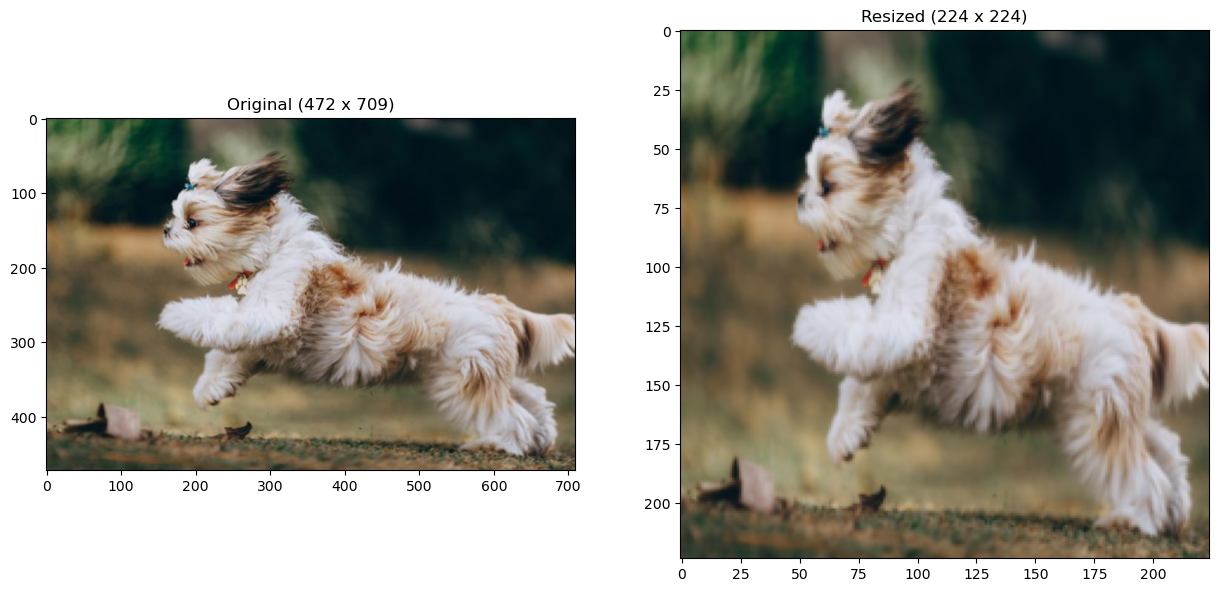

In [86]:
import matplotlib.pyplot as plt
%matplotlib inline

fig,ax = plt.subplots(1,2,figsize=(15,12))
ax[0].imshow(shihtzu_original_img.permute(1,2,0))
ax[1].imshow(shihtzu_resized_img.permute(1,2,0))
ax[0].set_title('Original (472 x 709)')
ax[1].set_title('Resized (224 x 224)')
print()

In [87]:
shihtzu_resized_img = shihtzu_resized_img.reshape(1,3,224,224)
print(shihtzu_resized_img.shape)

torch.Size([1, 3, 224, 224])


## Classifier

In [88]:
model.eval()
with torch.no_grad():
    X = shihtzu_resized_img.to(device)
    y = model(X)

pred = y.argmax(1).item()
print('Output shape:', y.shape)
print('Classe calculada:', pred, '(155 <-> Shih-Tzu)')

Output shape: torch.Size([1, 1000])
Classe calculada: 155 (155 <-> Shih-Tzu)


## Grad-CAM (Credits to: 'Grad-CAM: A beginner’s Guide' by Muskan Bhandari)

In [110]:
import cv2
import numpy as np

def heatmap(model, model_activation, img):
    model.eval()
    model_activation.eval()

    X = img.to(device)
    y = model(X)

    # [B,C,H,W] - Batch, Channels, ...
    activations = model_activation(X)

    pred = y.argmax(1).item()
    y[0,pred].backward(retain_graph=True)

    # shape of conv2d: [output_channels (0), input_channels, H (2), W (3)]
    pool_grads = model.layer4[-1].conv3.weight.grad.data.mean((1,2,3))

    for i in range(activations.shape[1]):
        activations[:,i,:,:] *= pool_grads[i]
    
    heatmap = torch.mean(activations, dim=1)[0].cpu().detach()
    return heatmap, pred

def upsampleHeatmap(heatmap, image):
    # permute image
    image = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
    # maximum and minimum value from heatmap
    m, M = heatmap.min(), heatmap.max()
    # normalize the heatmap
    heatmap = 255 * ((heatmap-m)/ (M-m))
    heatmap = np.uint8(heatmap)
    # resize the heatmap to the same as the input
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = cv2.applyColorMap(255-heatmap, cv2.COLORMAP_JET)
    heatmap = np.uint8(heatmap)
    # change this to balance between heatmap and image
    heatmap = np.uint8(heatmap*0.7 + image*0.3)
    return heatmap

In [111]:
def display_images(upsampled_map, image):
    image = image.squeeze(0).permute(1, 2, 0)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(upsampled_map)
    axes[0].set_title("Heatmap")
    axes[0].axis('off')
    axes[1].imshow(image)
    axes[1].set_title("Original Image")
    axes[1].axis('off')
    plt.show()

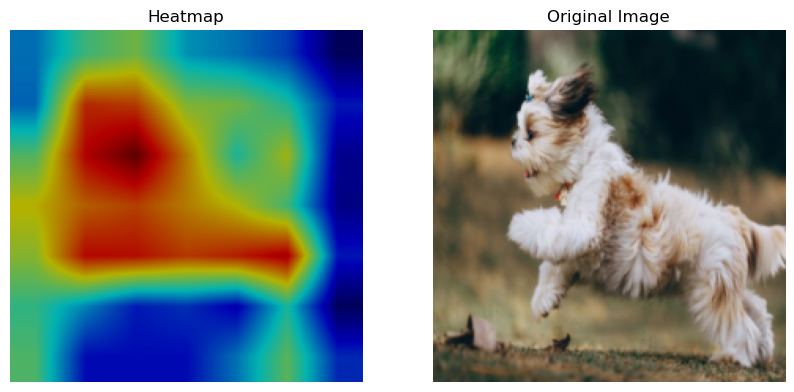

In [112]:
heatmap,pred = heatmap(model,model_activation,shihtzu_resized_img)
upsampled_map = upsampleHeatmap(heatmap,shihtzu_resized_img)

display_images(upsampled_map, shihtzu_resized_img)